### Imports

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

### Load the Data

In [62]:
table = pd.read_csv('diabetes.csv')

### Data Overview

In [63]:
table

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [64]:
table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [65]:
table.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## a)Exploratory Data Analysis (EDA)

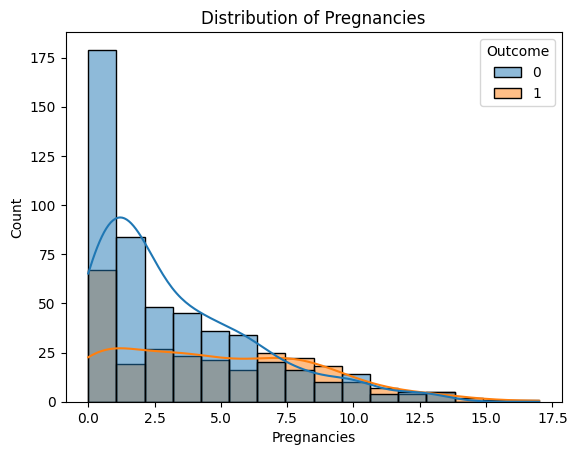

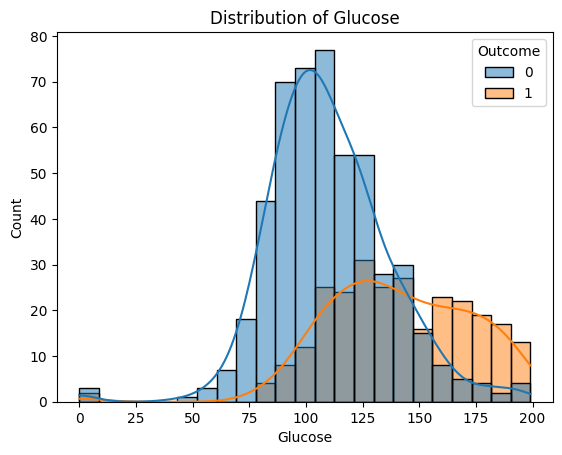

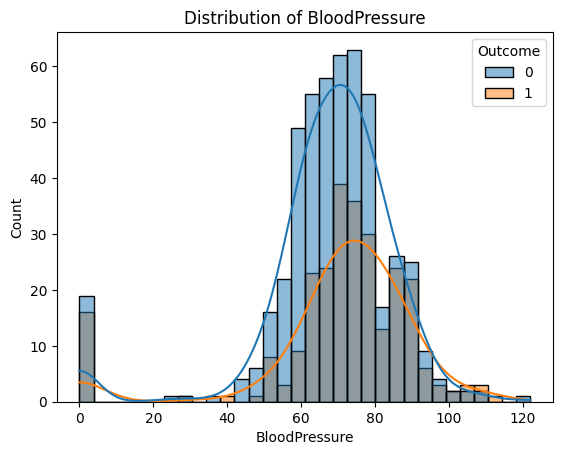

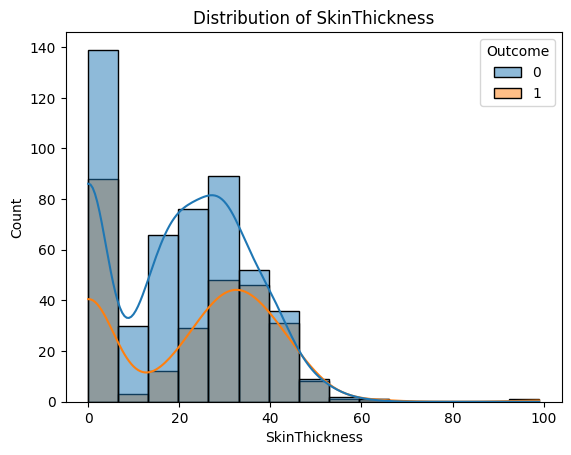

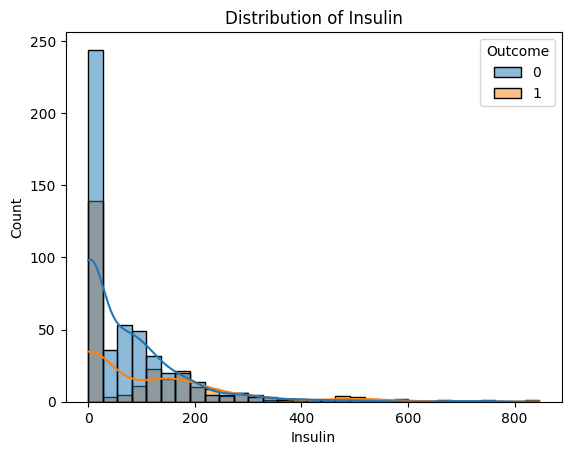

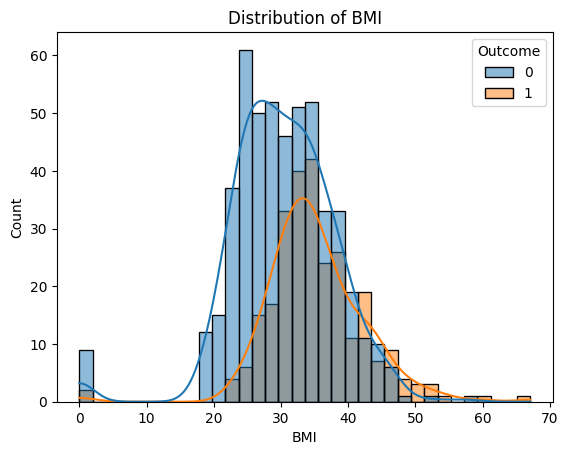

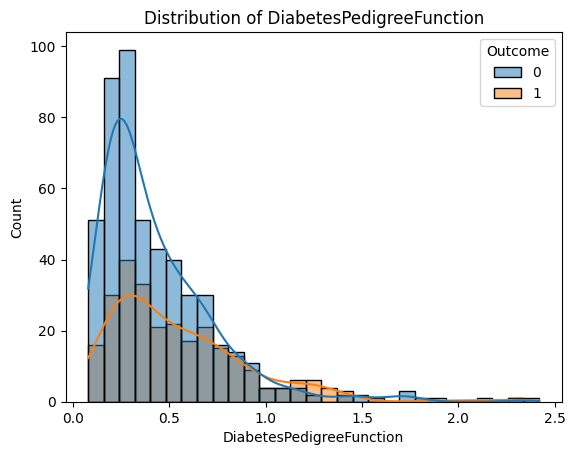

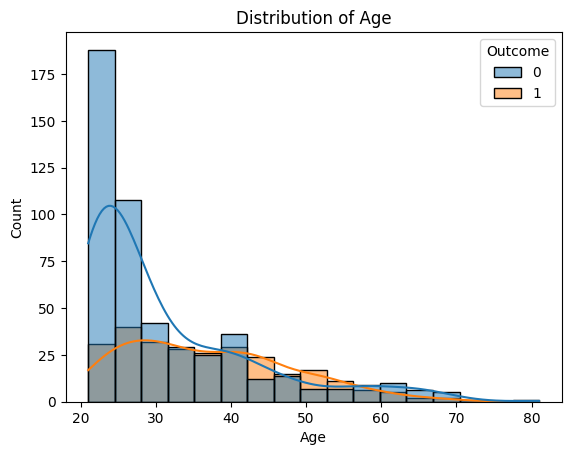

In [66]:
features = table.drop(columns='Outcome')
for col in features.columns:
    sns.histplot(data=table, x=col, hue='Outcome', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

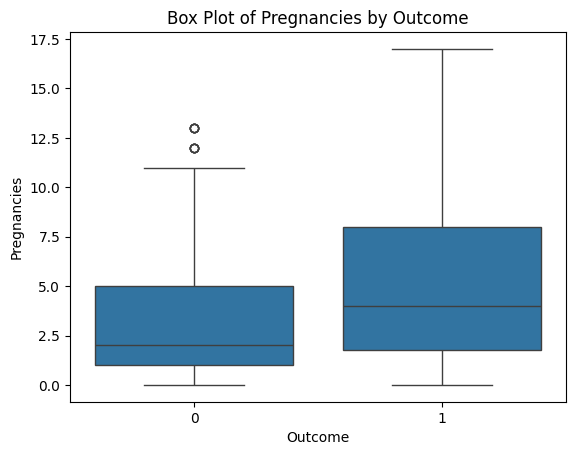

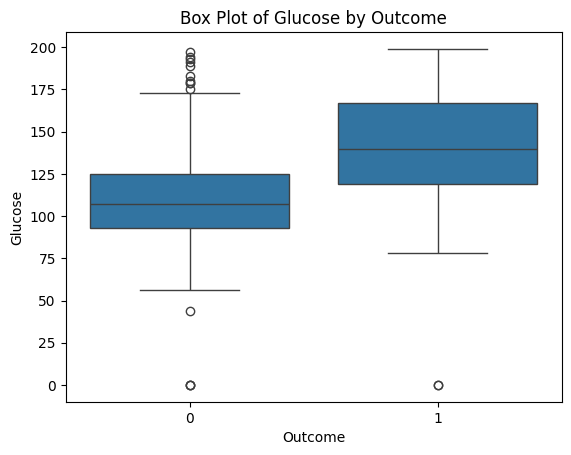

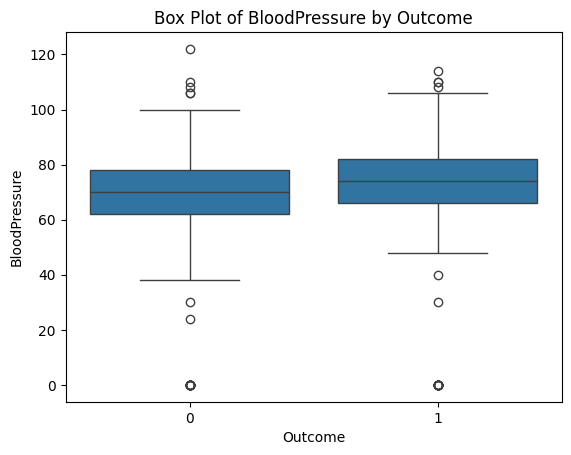

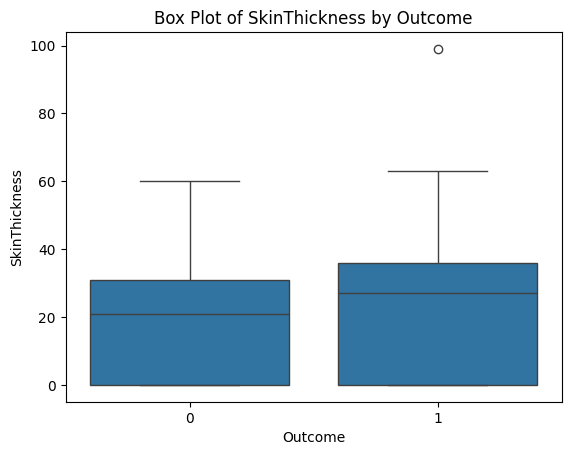

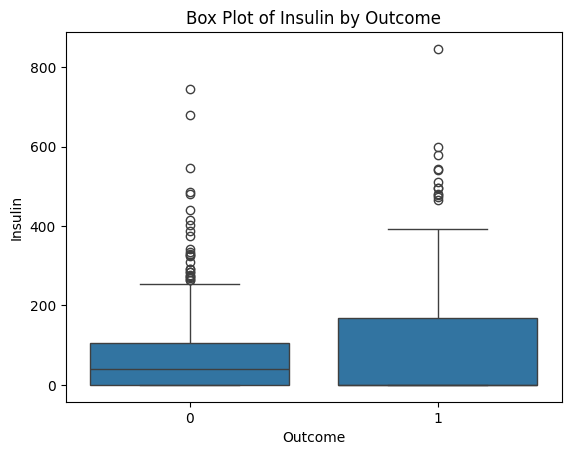

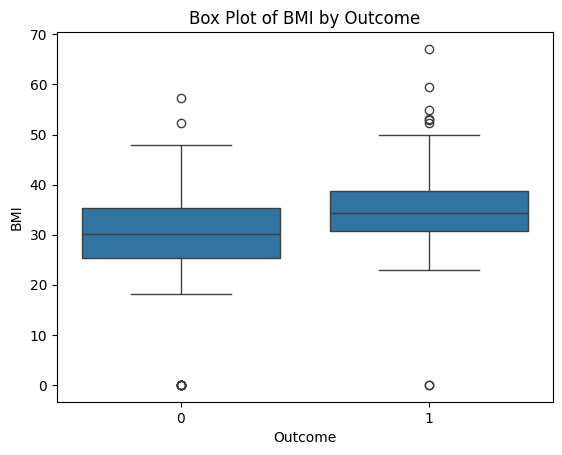

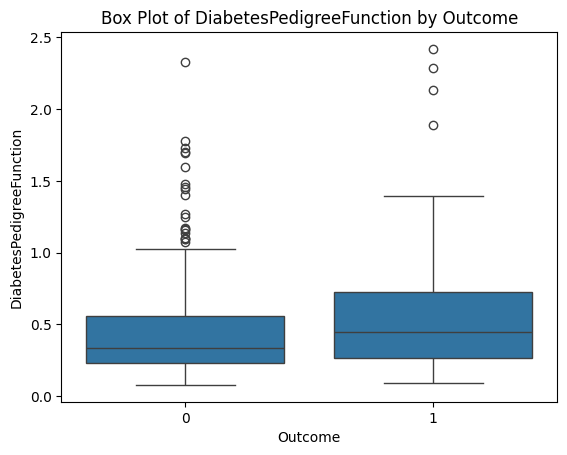

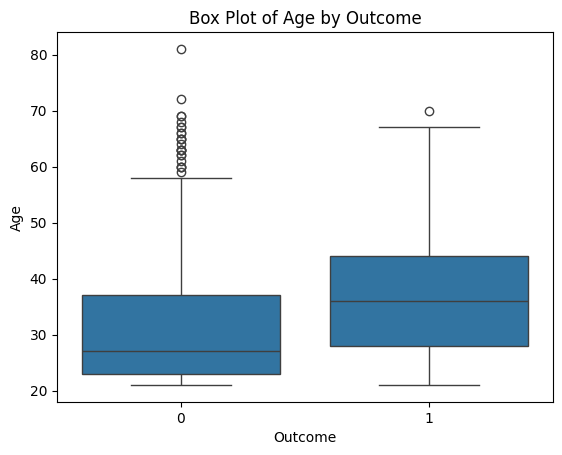

In [67]:
for col in features.columns:
    sns.boxplot(x='Outcome', y=col, data=table)
    plt.title(f'Box Plot of {col} by Outcome')
    plt.show()

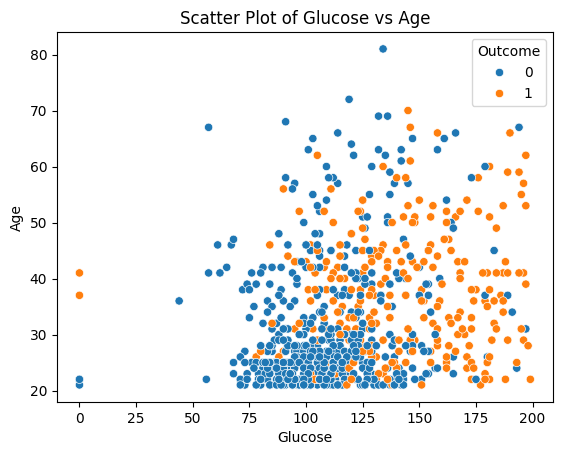

In [68]:
sns.scatterplot(data=table, x='Glucose', y='Age', hue='Outcome')
plt.title('Scatter Plot of Glucose vs Age')
plt.show()


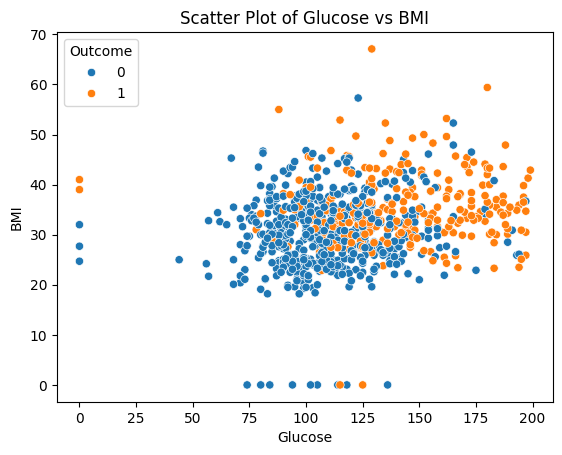

In [69]:
sns.scatterplot(data=table, x='Glucose', y='BMI', hue='Outcome')
plt.title('Scatter Plot of Glucose vs BMI')
plt.show()

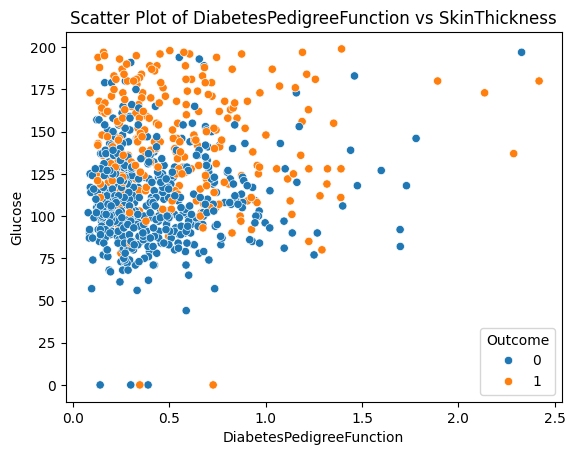

In [70]:
sns.scatterplot(data=table, x='DiabetesPedigreeFunction', y='Glucose', hue='Outcome')
plt.title('Scatter Plot of DiabetesPedigreeFunction vs SkinThickness')
plt.show()

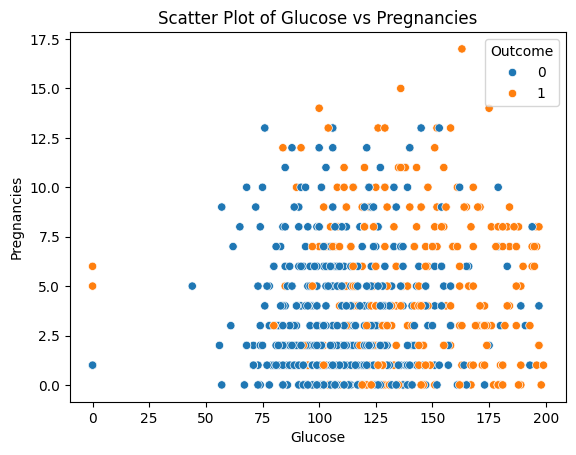

In [71]:
sns.scatterplot(data=table, x='Glucose', y='Pregnancies', hue='Outcome')
plt.title('Scatter Plot of Glucose vs Pregnancies')
plt.show()

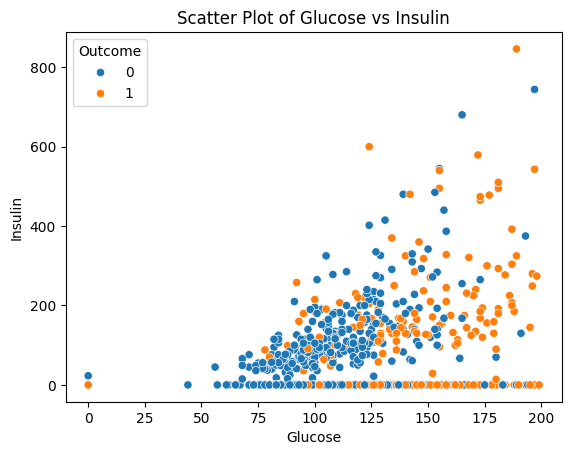

In [72]:
sns.scatterplot(data=table, x='Glucose', y='Insulin', hue='Outcome')
plt.title('Scatter Plot of Glucose vs Insulin')
plt.show()

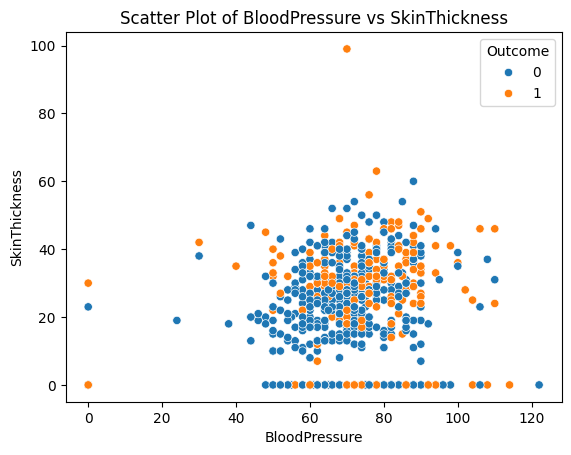

In [73]:
sns.scatterplot(data=table, x='BloodPressure', y='SkinThickness', hue='Outcome')
plt.title('Scatter Plot of BloodPressure vs SkinThickness')
plt.show()

## b)Preprocessing


#### Split data

In [92]:
y = table['Outcome']							
X = table[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)


#### <font color=red> ********** wrong way!! **********</font> ###

In [75]:
X_train[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction']] = X_train[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction']].replace(0, np.nan)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

X_test[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction']] = X_test[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction']].replace(0, np.nan)
train_means = X_train.mean()
X_test_imputed = X_test.fillna(train_means)


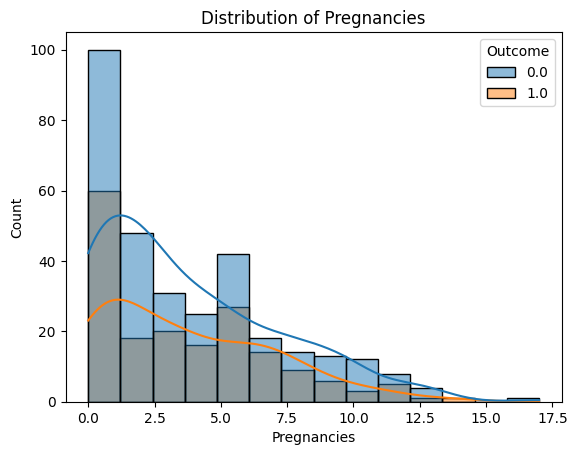

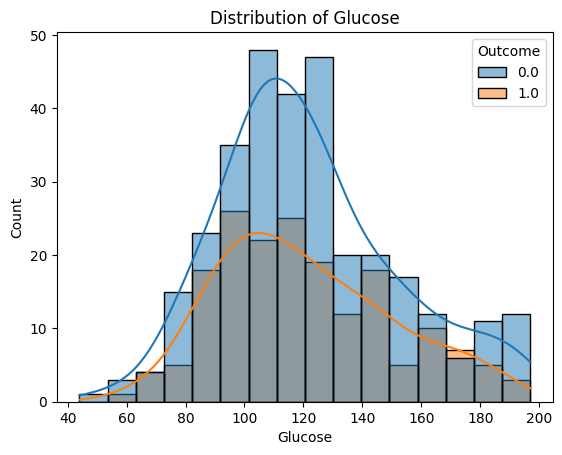

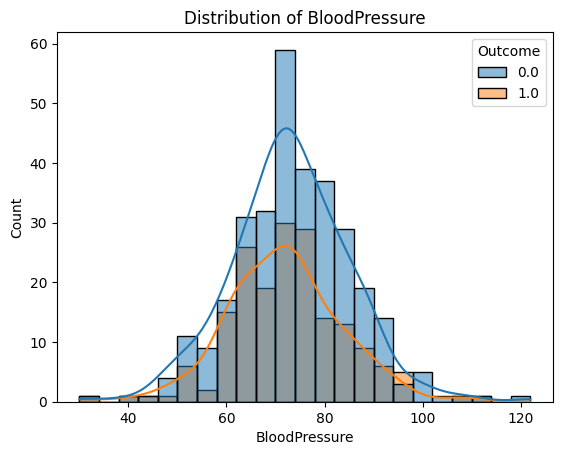

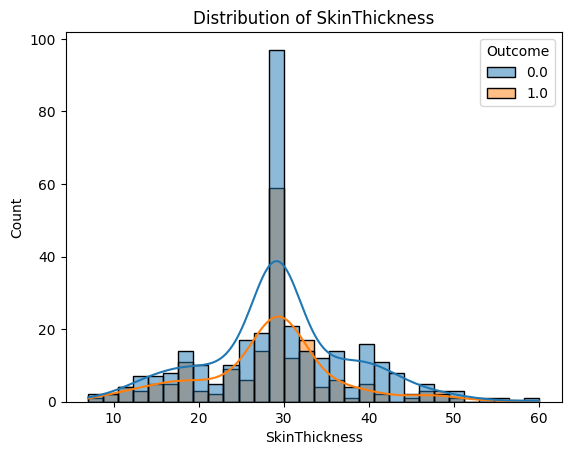

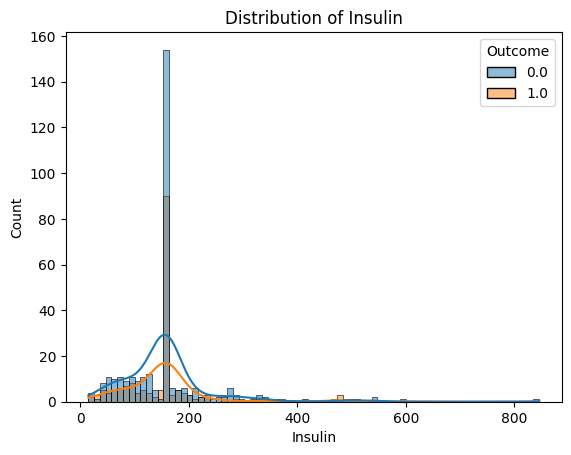

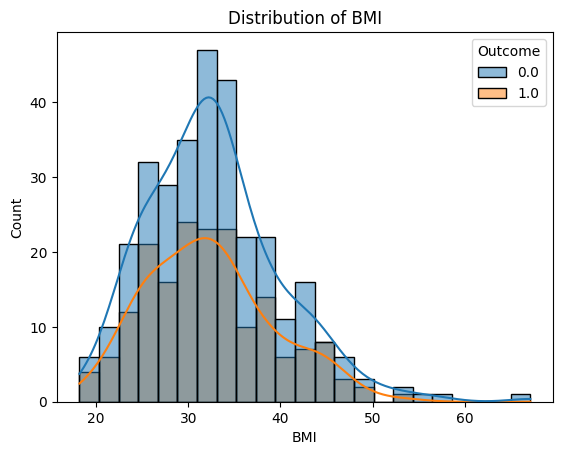

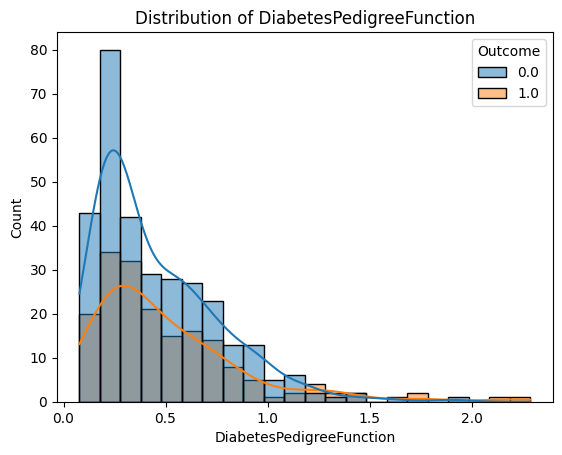

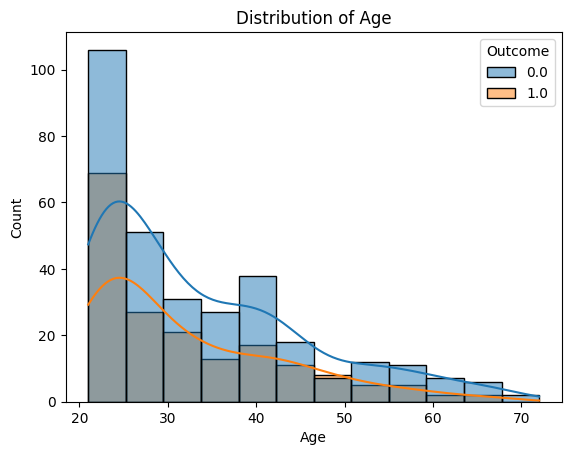

In [76]:
combined_table = pd.concat([X_train_imputed, y_train], axis=1)
features = combined_table.drop(columns='Outcome')
for col in features.columns:
    sns.histplot(data=combined_table, x=col, hue='Outcome', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [77]:
columns_zscore = ['BMI', 'BloodPressure' , 'Glucose' , 'Insulin' , 'SkinThickness']
columns_iqr = ['DiabetesPedigreeFunction','Age']

X_train_no_outliers = X_train_imputed.copy()

threshold = 3  
for column in columns_zscore:
    z_scores = np.abs(zscore(X_train_no_outliers[column]))
    mean_value = X_train_no_outliers[column].mean()
    X_train_no_outliers.loc[z_scores > threshold, column] = mean_value

for column in columns_iqr:
    Q1 = X_train_no_outliers[column].quantile(0.25)
    Q3 = X_train_no_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_value = X_train_no_outliers[column].median()
    X_train_no_outliers.loc[(X_train_no_outliers[column] < lower_bound) | (X_train_no_outliers[column] > upper_bound), column] = median_value

Q1 = X_train_no_outliers['Pregnancies'].quantile(0.25)
Q3 = X_train_no_outliers['Pregnancies'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mmode_value = X_train_no_outliers['Pregnancies'].mode()[0]
X_train_no_outliers.loc[(X_train_no_outliers['Pregnancies'] < lower_bound) | (X_train_no_outliers['Pregnancies'] > upper_bound), 'Pregnancies'] = mmode_value

X_train_no_outliers


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2.0,93.00000,64.0,32.000000,160.000000,38.0,0.674,23.0
1,4.0,184.00000,78.0,39.000000,277.000000,37.0,0.264,31.0
2,2.0,125.00000,60.0,20.000000,140.000000,33.8,0.088,31.0
3,7.0,114.00000,64.0,29.191686,157.473186,27.4,0.732,34.0
4,2.0,117.00000,90.0,19.000000,71.000000,25.2,0.313,21.0
...,...,...,...,...,...,...,...,...
609,1.0,121.52381,48.0,20.000000,157.473186,24.7,0.140,22.0
610,1.0,109.00000,38.0,18.000000,120.000000,23.1,0.407,26.0
611,1.0,119.00000,44.0,47.000000,63.000000,35.5,0.280,25.0
612,5.0,115.00000,76.0,29.191686,157.473186,31.2,0.343,44.0


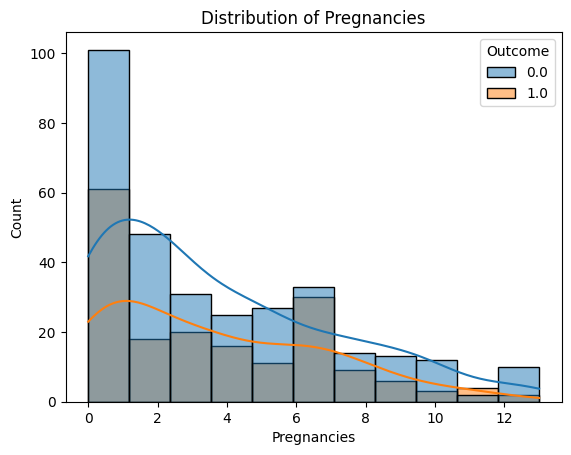

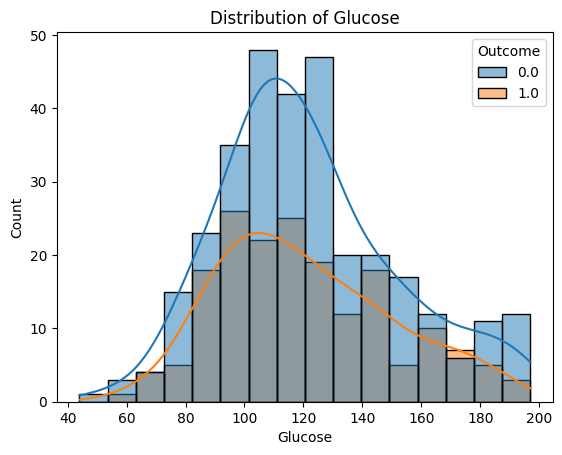

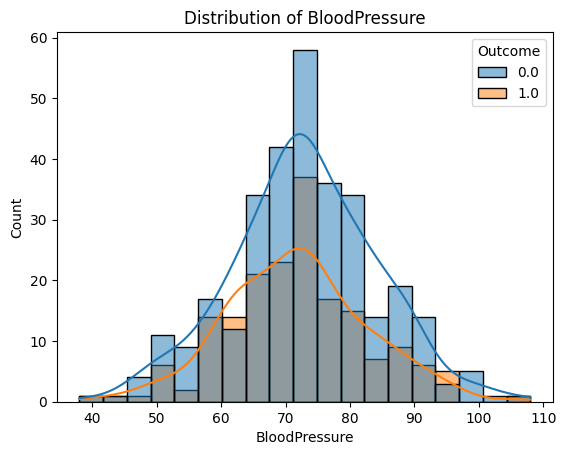

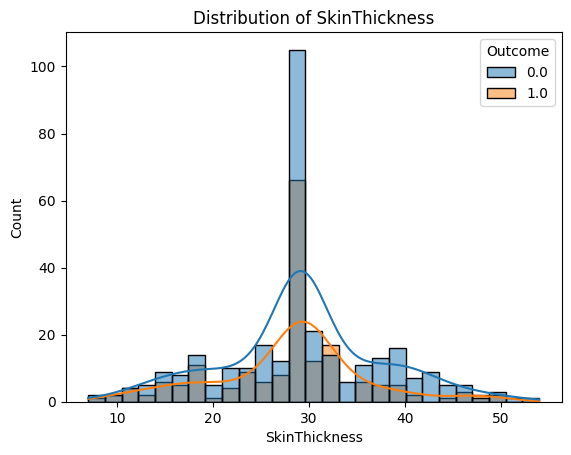

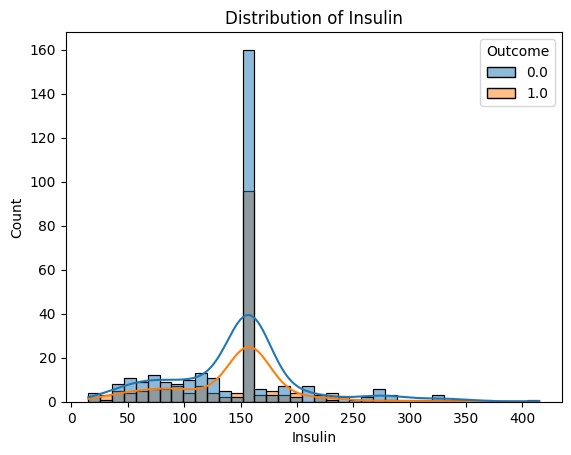

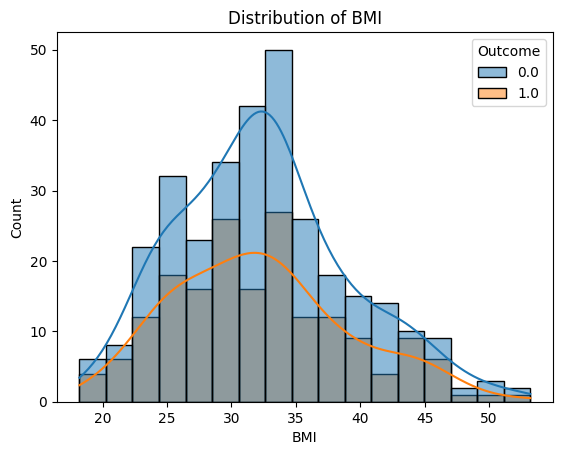

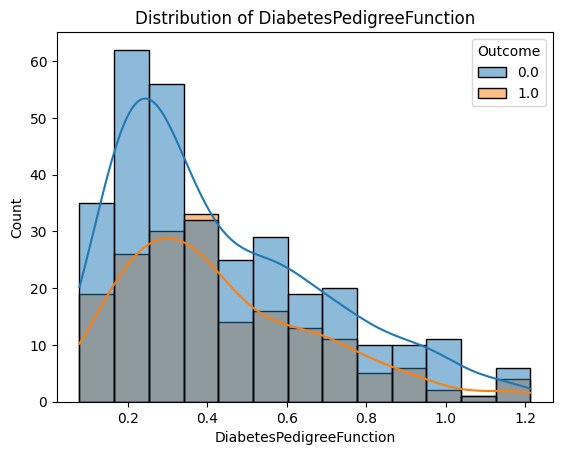

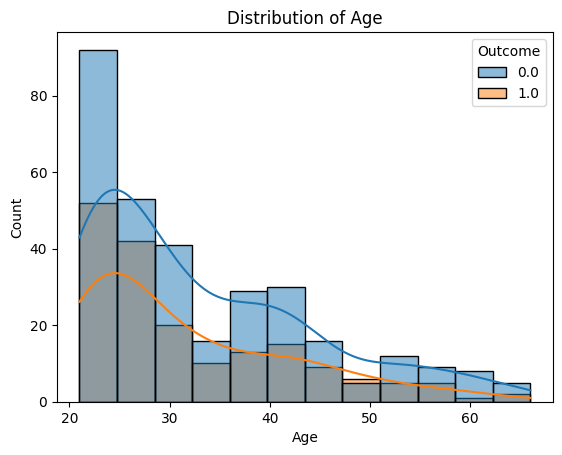

In [78]:
combined_table = pd.concat([X_train_no_outliers, y_train], axis=1)
features = combined_table.drop(columns='Outcome')
for col in features.columns:
    sns.histplot(data=combined_table, x=col, hue='Outcome', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

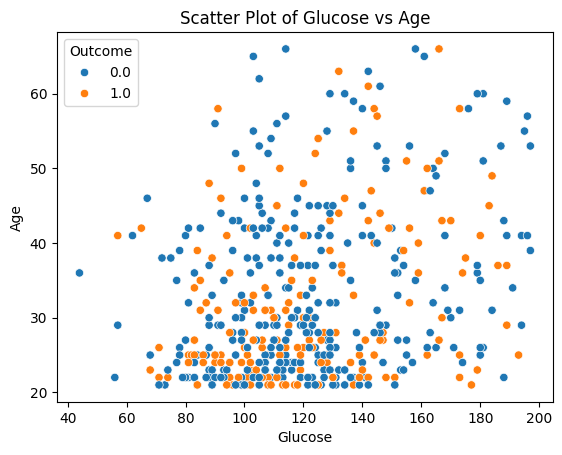

In [79]:
sns.scatterplot(data=combined_table, x='Glucose', y='Age', hue='Outcome')
plt.title('Scatter Plot of Glucose vs Age')
plt.show()

#### <font color=red> ******************************</font> ###

#### Select features (Pregnancies , Glucose , BMI , DiabetesPedigreeFunction , Age)

In [80]:
X_train_selected = X_train[['Pregnancies' , 'Glucose' , 'BMI' , 'DiabetesPedigreeFunction' , 'Age'] ].astype(float)


#### dropping missing data

In [81]:
X_train_selected.loc[:, ['Glucose', 'BMI', 'DiabetesPedigreeFunction']] = X_train_selected[['Glucose', 'BMI', 'DiabetesPedigreeFunction']].replace(0, np.nan)
combined_table = pd.concat([X_train_selected, y_train], axis=1)
combined_table_cleaned = combined_table.dropna()
X_train_cleaned = combined_table_cleaned[['Pregnancies' , 'Glucose' , 'BMI' , 'DiabetesPedigreeFunction' , 'Age']]
y_train_cleaned = combined_table_cleaned['Outcome']
combined_table_cleaned

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age,Outcome
709,2.0,93.0,38.0,0.674,23.0,1
425,4.0,184.0,37.0,0.264,31.0,1
135,2.0,125.0,33.8,0.088,31.0,0
630,7.0,114.0,27.4,0.732,34.0,1
500,2.0,117.0,25.2,0.313,21.0,0
...,...,...,...,...,...,...
393,4.0,116.0,22.1,0.463,37.0,0
599,1.0,109.0,23.1,0.407,26.0,0
575,1.0,119.0,35.5,0.280,25.0,0
337,5.0,115.0,31.2,0.343,44.0,1


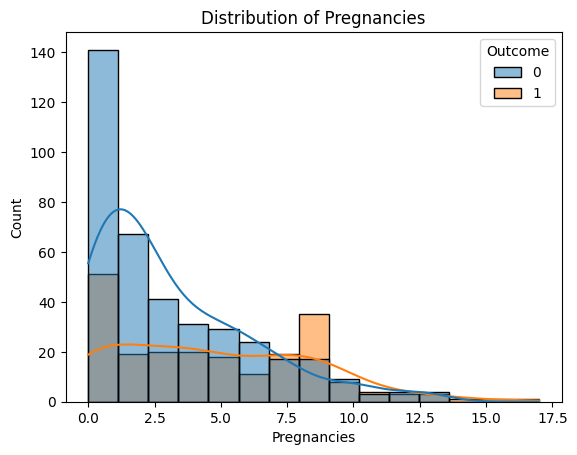

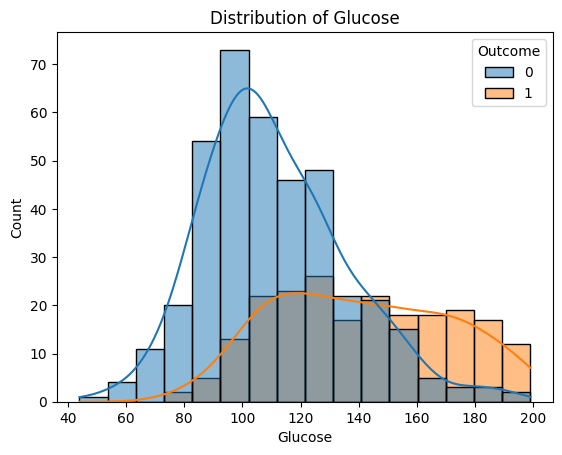

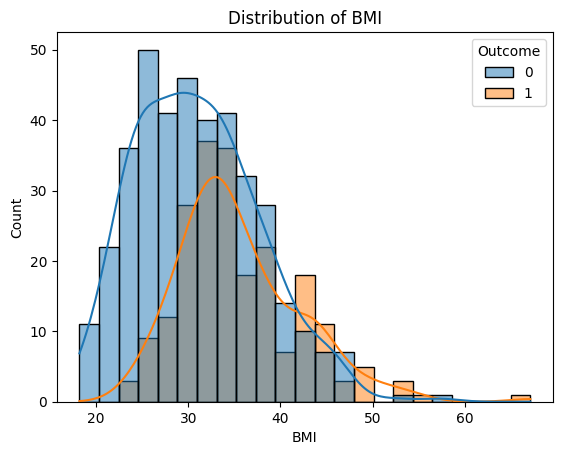

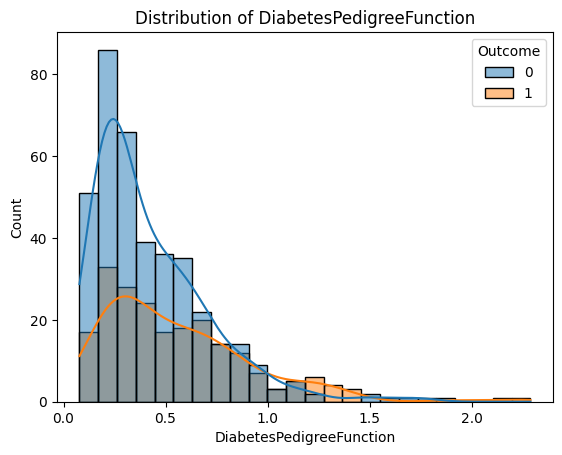

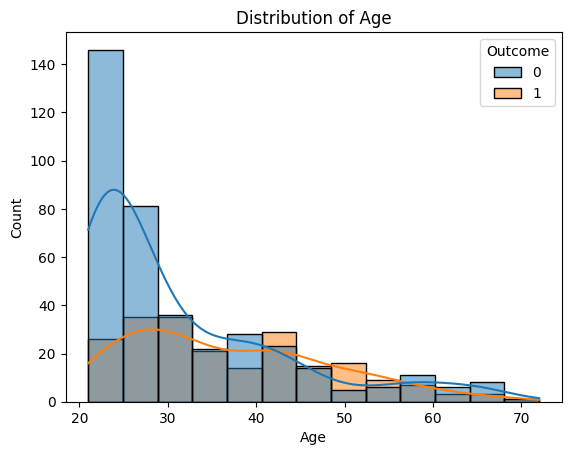

In [82]:
features = combined_table_cleaned.drop(columns='Outcome')
for col in features.columns:
    sns.histplot(data=combined_table_cleaned, x=col, hue='Outcome', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#### Replace outliers

In [83]:
X_train_no_outliers = X_train_cleaned.copy()


threshold = 3  
z_scores = np.abs(zscore(X_train_no_outliers['BMI']))
mean_value = X_train_no_outliers['BMI'].mean()
X_train_no_outliers.loc[z_scores > threshold, 'BMI'] = mean_value


Q1 = X_train_no_outliers['Pregnancies'].quantile(0.25)
Q3 = X_train_no_outliers['Pregnancies'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mmode_value = X_train_no_outliers['Pregnancies'].mode()[0]
X_train_no_outliers.loc[(X_train_no_outliers['Pregnancies'] < lower_bound) | (X_train_no_outliers['Pregnancies'] > upper_bound), 'Pregnancies'] = mmode_value


Q1 = X_train_no_outliers['DiabetesPedigreeFunction'].quantile(0.25)
Q3 = X_train_no_outliers['DiabetesPedigreeFunction'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
median_value = X_train_no_outliers['DiabetesPedigreeFunction'].median()
X_train_no_outliers.loc[(X_train_no_outliers['DiabetesPedigreeFunction'] < lower_bound) | (X_train_no_outliers['DiabetesPedigreeFunction'] > upper_bound), 'DiabetesPedigreeFunction'] = median_value


Q1 = X_train_no_outliers['Age'].quantile(0.25)
Q3 = X_train_no_outliers['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
median_value = X_train_no_outliers['Age'].median()
X_train_no_outliers.loc[(X_train_no_outliers['Age'] < lower_bound) | (X_train_no_outliers['Age'] > upper_bound), 'Age'] = median_value

X_train_final = X_train_no_outliers.copy()
y_train_final = y_train_cleaned.copy()


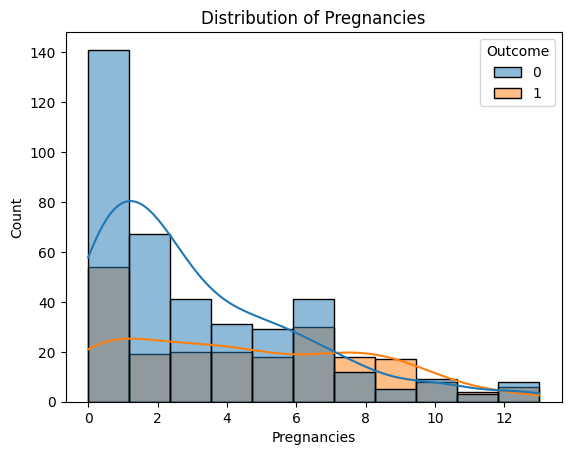

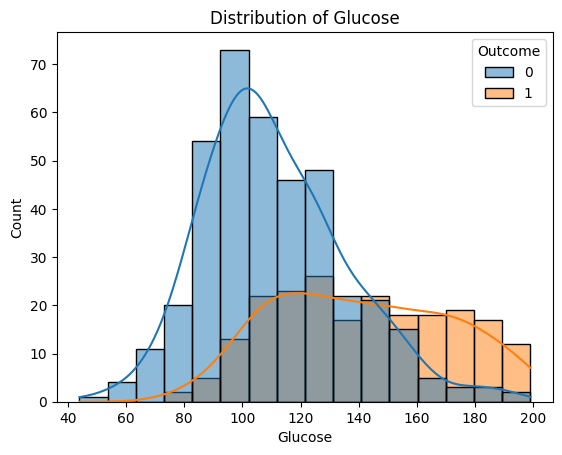

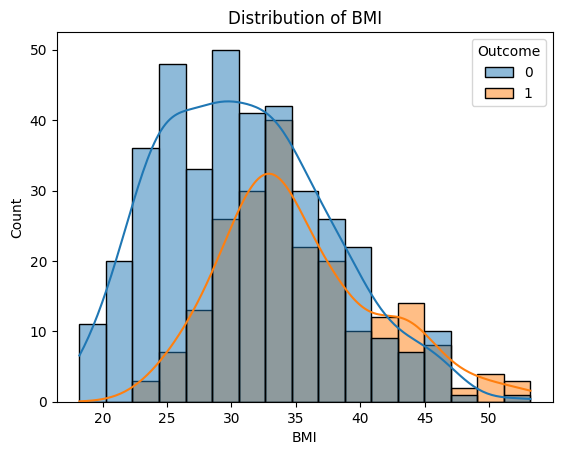

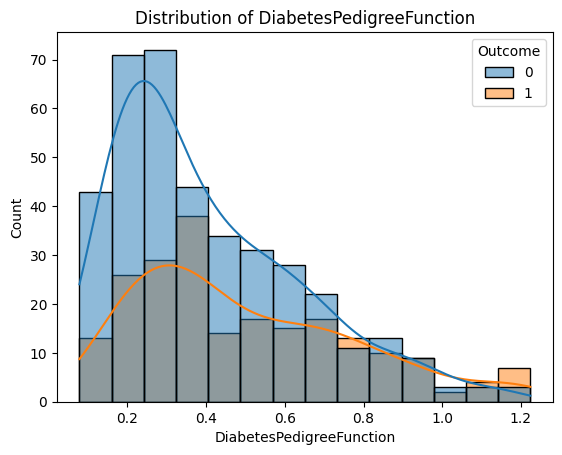

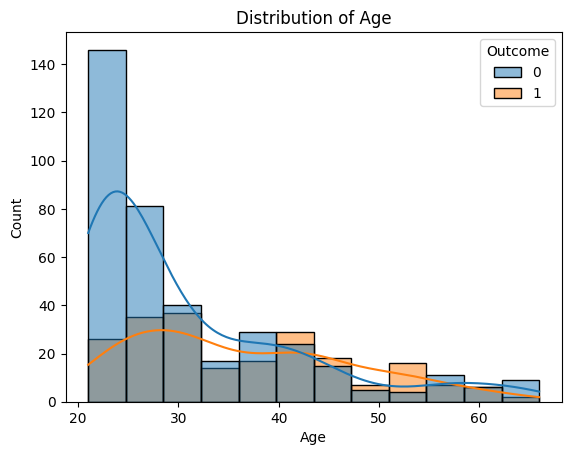

In [84]:
combined_table_1 = pd.concat([X_train_no_outliers, y_train_cleaned], axis=1)
features = combined_table_1.drop(columns='Outcome')
for col in features.columns:
    sns.histplot(data=combined_table_1, x=col, hue='Outcome', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

## c)Classification:

#### Replace missing data (in test data)

In [104]:
X_test_selected = X_test[['Pregnancies' , 'Glucose' , 'BMI' , 'DiabetesPedigreeFunction' , 'Age'] ].astype(float)
X_test_selected[['Glucose','BMI','DiabetesPedigreeFunction']] = X_test_selected[['Glucose','BMI','DiabetesPedigreeFunction']].replace(0, np.nan)
X_test_selected
train_means = X_train_final.mean()
X_test_final = X_test_selected.fillna(train_means)

In [105]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_final, y_train_final)
y_pred = logistic_model.predict(X_test_final)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       103
           1       0.72      0.65      0.68        51

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.80      0.80       154

Confusion Matrix:
 [[90 13]
 [18 33]]
Precision: 0.717391304347826
Accuracy: 0.7987012987012987


## c)Normalization & Standardization:

#### Standardization

In [114]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_final.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)

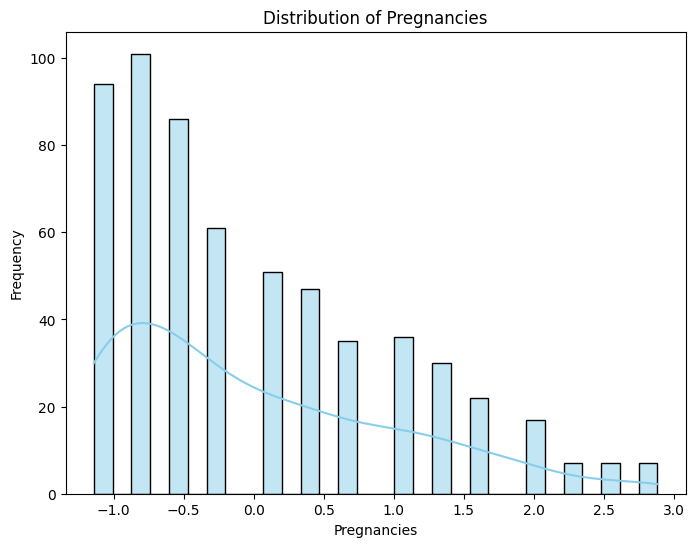

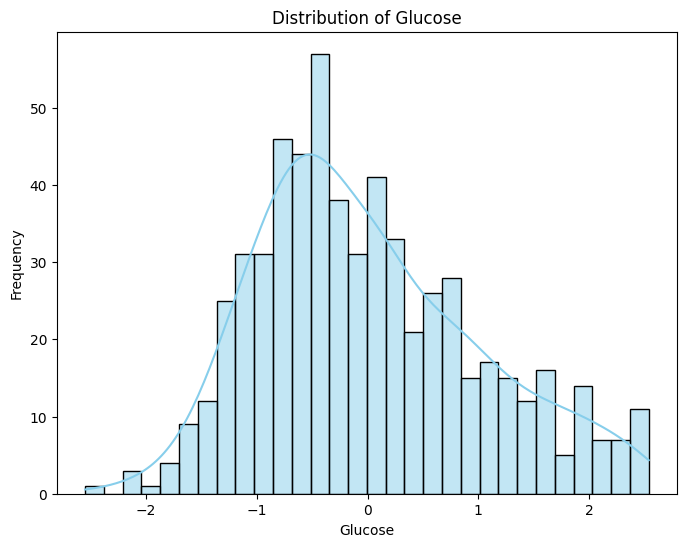

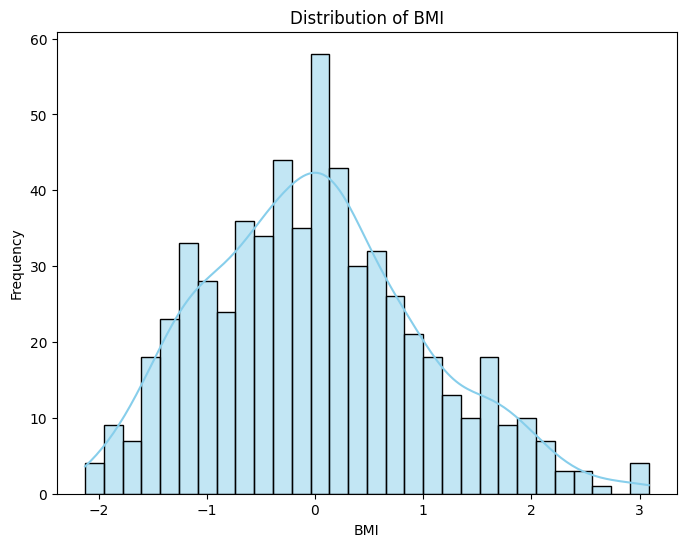

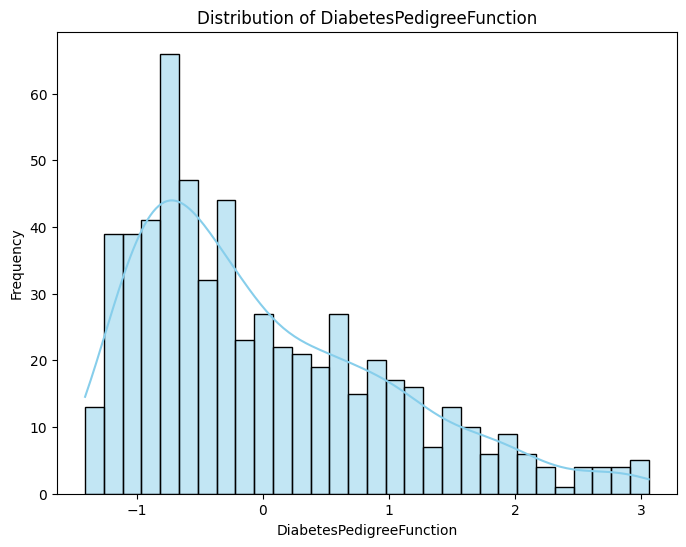

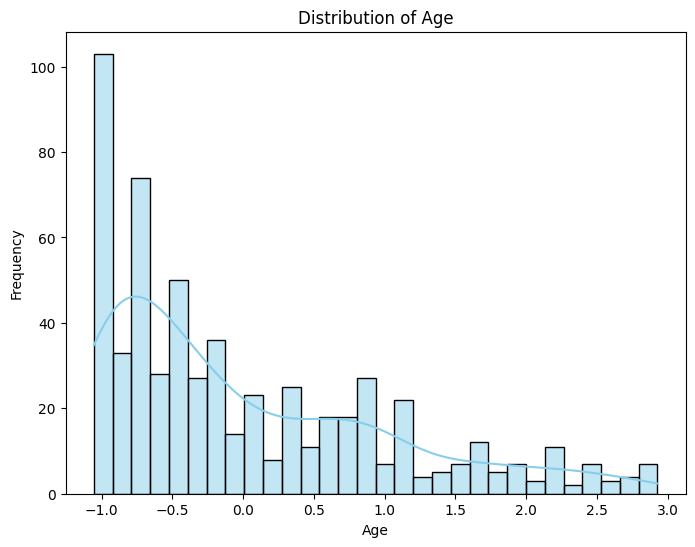

In [115]:
for col in X_train_scaled_df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(X_train_scaled_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [118]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled_df, y_train_final)
y_pred = logistic_model.predict(X_test_scaled_df)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       103
           1       0.72      0.65      0.68        51

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.80      0.80       154

Confusion Matrix:
 [[90 13]
 [18 33]]
Precision: 0.717391304347826
Accuracy: 0.7987012987012987


#### Normalization

In [116]:
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train_final)
X_test_normalized = scaler.transform(X_test_final)

X_train_normalized_df = pd.DataFrame(X_train_normalized, columns=X_train_final.columns)
X_test_normalized_df = pd.DataFrame(X_test_normalized, columns=X_test_final.columns)

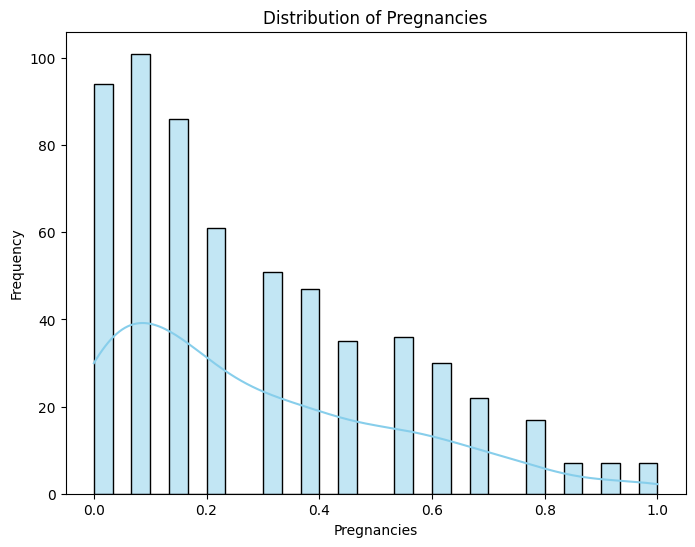

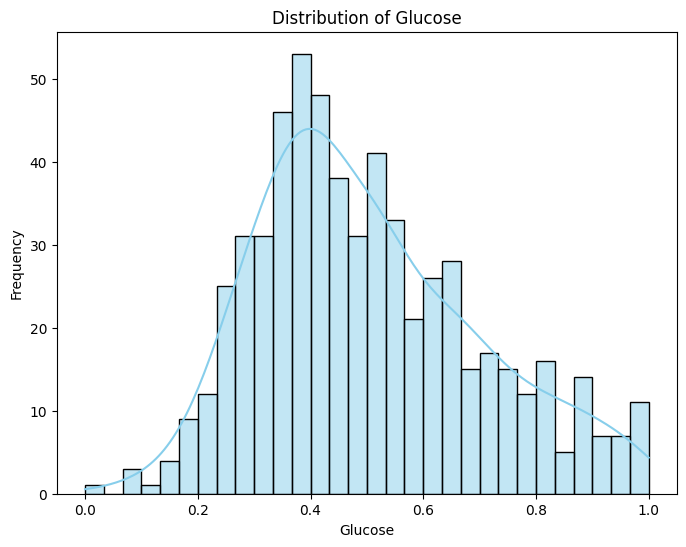

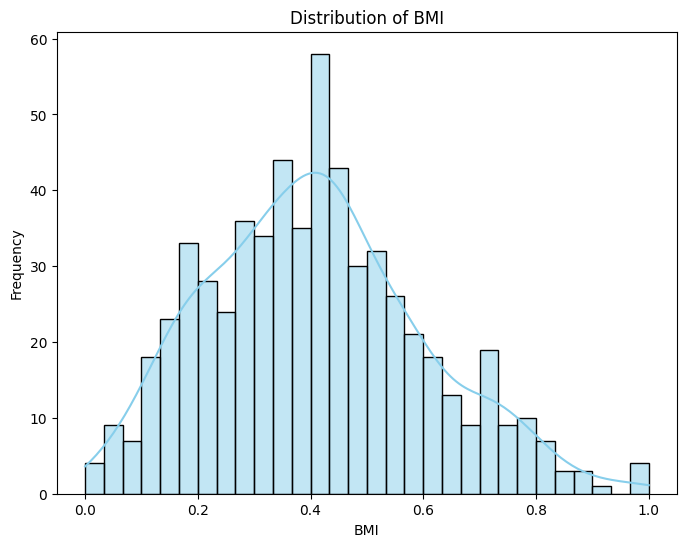

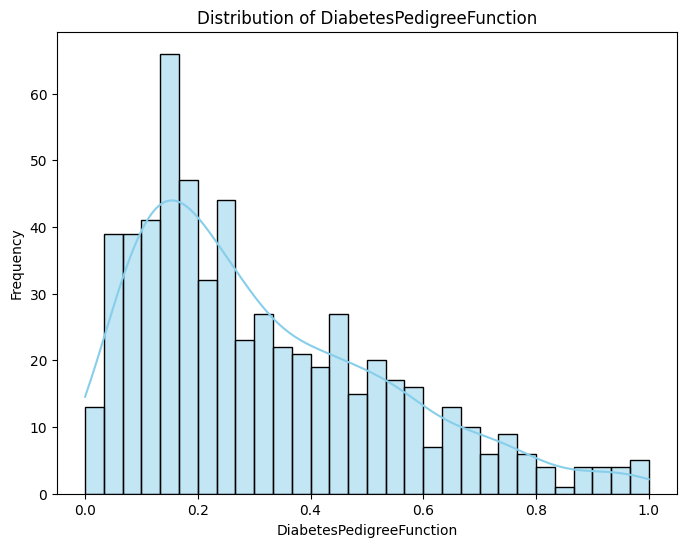

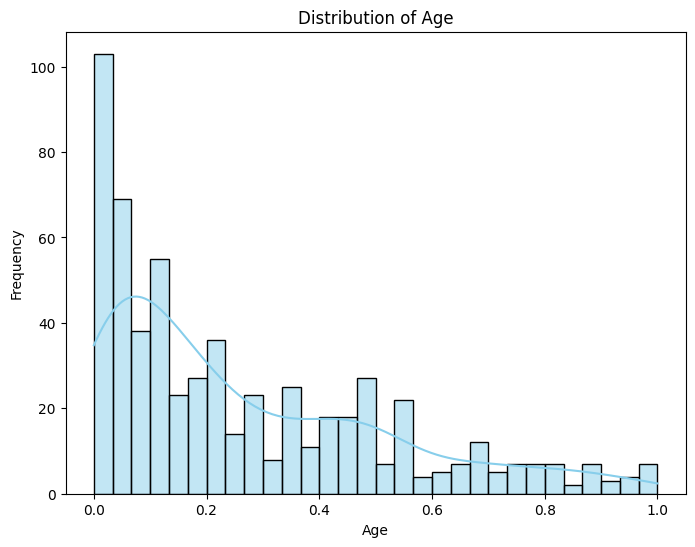

In [117]:
for col in X_train_normalized_df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(X_train_normalized_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [119]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_normalized_df, y_train_final)
y_pred = logistic_model.predict(X_test_normalized_df)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.85       103
           1       0.70      0.61      0.65        51

    accuracy                           0.79       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.78      0.79      0.78       154

Confusion Matrix:
 [[90 13]
 [20 31]]
Precision: 0.7045454545454546
Accuracy: 0.7857142857142857
